In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
)


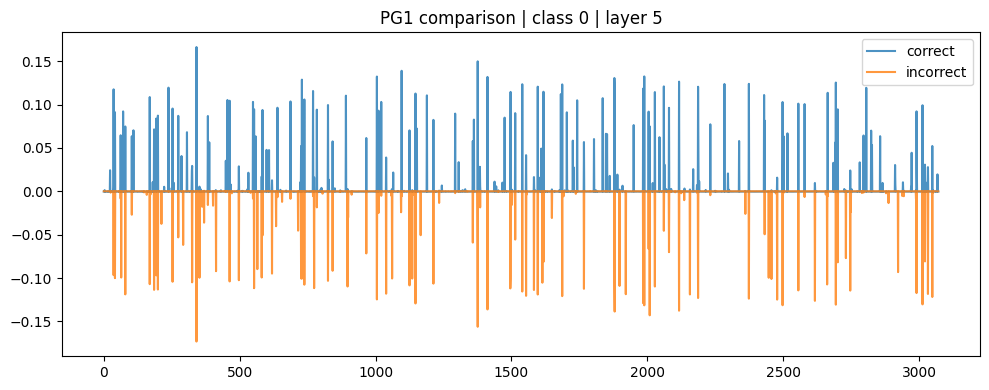

In [2]:
cls = 0
layer = 5
base = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/pg"

pg_c = np.load(f"{base}/correct/pg1_data/{cls}_layer{layer}_ffn_pg1.npy")
pg_i = np.load(f"{base}/incorrect/pg1_data/{cls}_layer{layer}_ffn_pg1.npy")

plt.figure(figsize=(10,4))
plt.plot(pg_c, label="correct", alpha=0.8)
plt.plot(pg_i, label="incorrect", alpha=0.8)
plt.title(f"PG1 comparison | class {cls} | layer {layer}")
plt.legend()
plt.tight_layout()
plt.show()

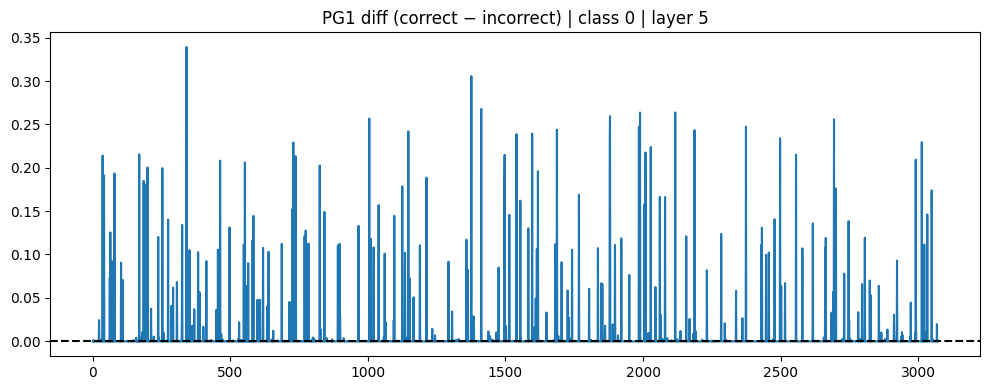

In [3]:
diff = pg_c - pg_i

plt.figure(figsize=(10,4))
plt.plot(diff)
plt.axhline(0, color="black", linestyle="--")
plt.title(f"PG1 diff (correct − incorrect) | class {cls} | layer {layer}")
plt.tight_layout()
plt.show()

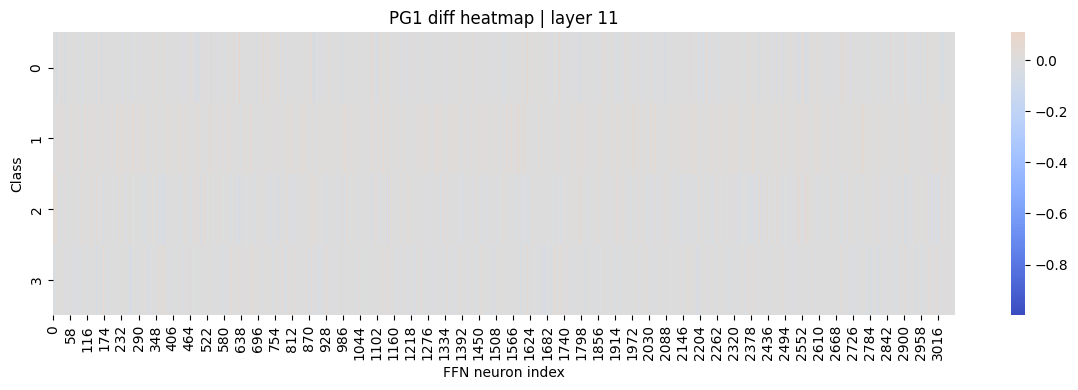

In [4]:
import seaborn as sns

layer = 11
diffs = []

for cls in range(4):
    pg_c = np.load(f"{base}/correct/pg1_data/{cls}_layer{layer}_ffn_pg1.npy")
    pg_i = np.load(f"{base}/incorrect/pg1_data/{cls}_layer{layer}_ffn_pg1.npy")
    diffs.append(pg_c - pg_i)

diffs = np.array(diffs)  # classes × units

plt.figure(figsize=(12,4))
sns.heatmap(diffs, cmap="coolwarm", center=0)
plt.xlabel("FFN neuron index")
plt.ylabel("Class")
plt.title(f"PG1 diff heatmap | layer {layer}")
plt.tight_layout()
plt.show()

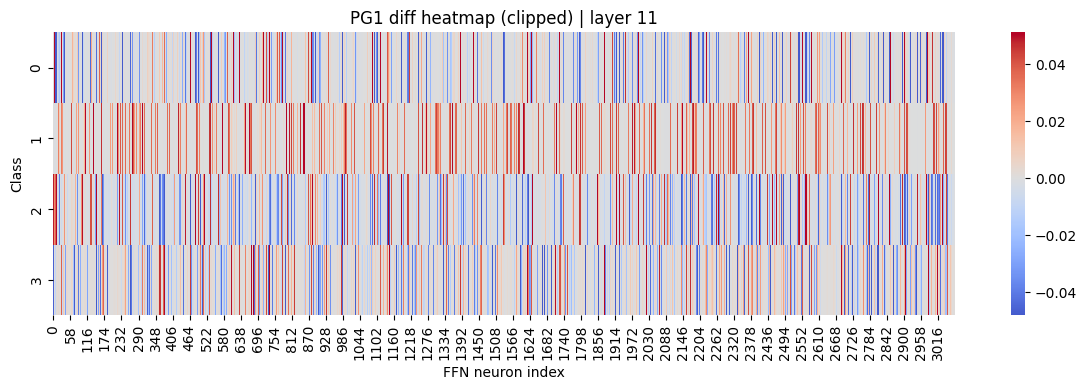

In [5]:
v = diffs.flatten()
vmin, vmax = np.percentile(v, [2, 98])   # clip extremes

plt.figure(figsize=(12,4))
sns.heatmap(diffs, cmap="coolwarm", center=0, vmin=vmin, vmax=vmax)
plt.title(f"PG1 diff heatmap (clipped) | layer {layer}")
plt.xlabel("FFN neuron index")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

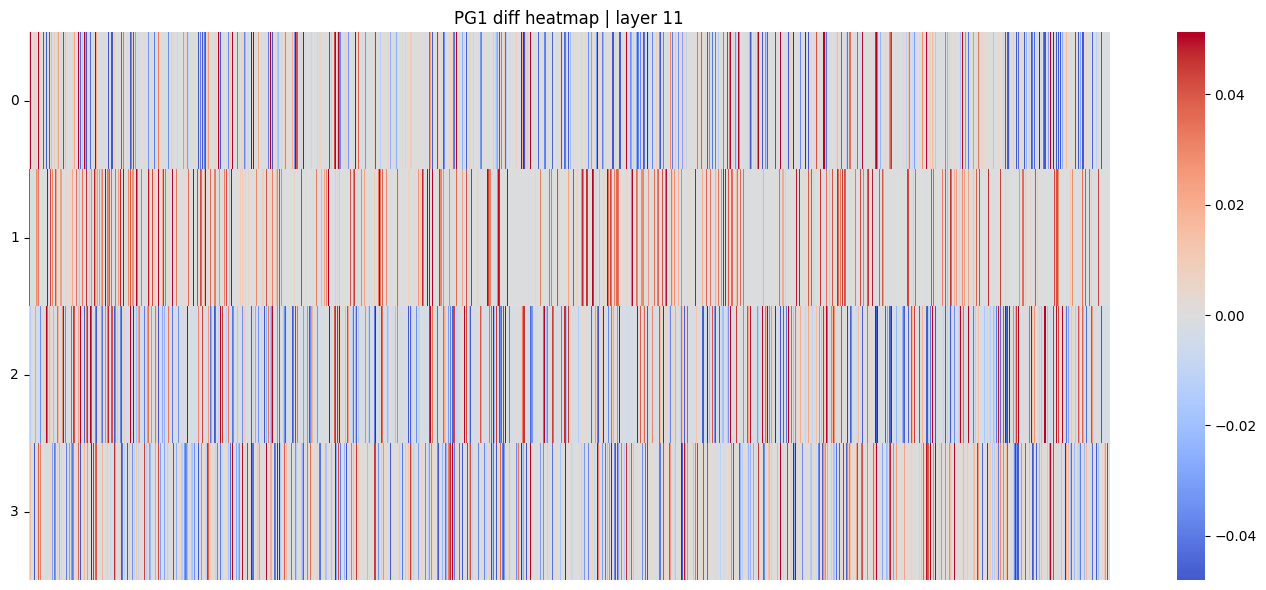

In [6]:
plt.figure(figsize=(14,6))
sns.heatmap(diffs, cmap="coolwarm", center=0, vmin=vmin, vmax=vmax)
plt.yticks(rotation=0)
plt.xticks([])  # hide x ticks (too many neurons)
plt.title(f"PG1 diff heatmap | layer {layer}")
plt.tight_layout()
plt.show()

In [7]:
import os, torch
act_base = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/activations"

for cls in range(4):
    files = [f for f in os.listdir(f"{act_base}/class_{cls}") if f.endswith(".pt")]
    corr = 0
    for f in files:
        corr += int(torch.load(f"{act_base}/class_{cls}/{f}")["correct"])
    print(cls, "total", len(files), "correct", corr, "incorrect", len(files)-corr)

/tmp/ipykernel_872738/1572636381.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  corr += int(torch.load(f"{act_base}/class_{cls}/{f}")["correct"])


0 total 187 correct 100 incorrect 87
1 total 124 correct 100 incorrect 24
2 total 200 correct 100 incorrect 100
3 total 200 correct 100 incorrect 100


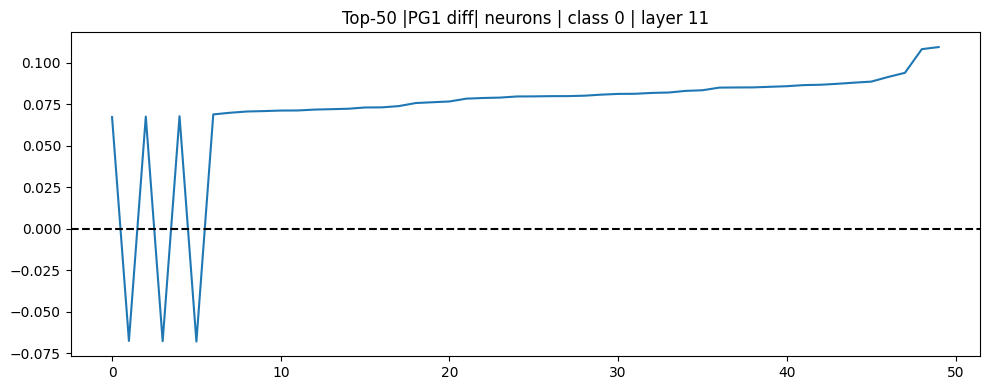

In [8]:
cls = 0
d = diffs[cls]
topk = np.argsort(np.abs(d))[-50:]   # top 50 neurons

plt.figure(figsize=(10,4))
plt.plot(d[topk])
plt.title(f"Top-50 |PG1 diff| neurons | class {cls} | layer {layer}")
plt.axhline(0, color="black", ls="--")
plt.tight_layout()
plt.show()

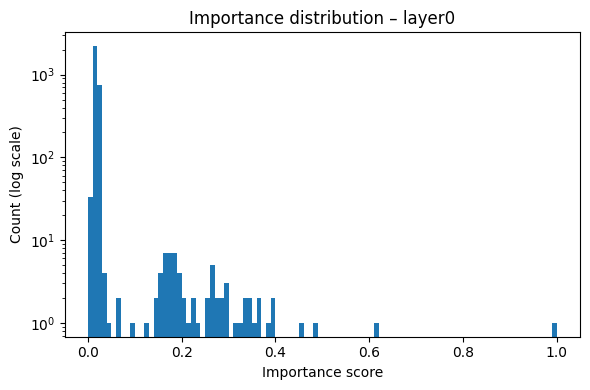

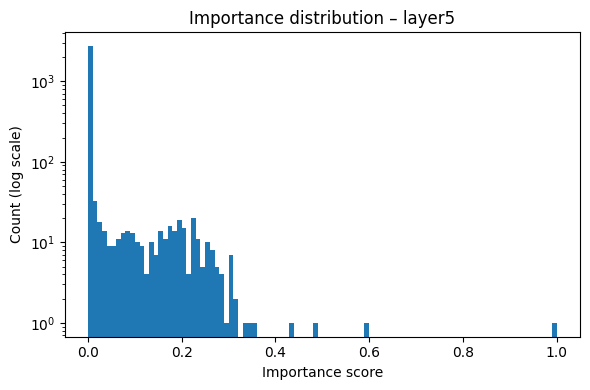

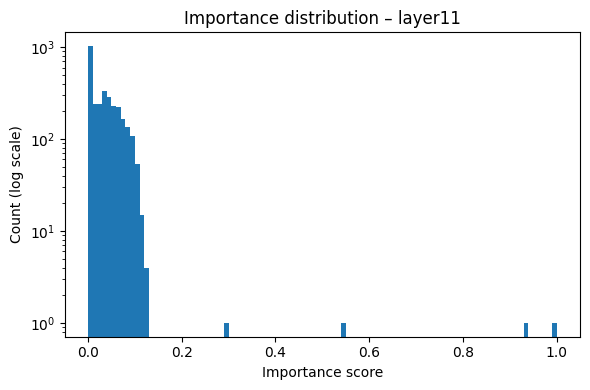

In [9]:
imp = np.load("/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/new/importance_ffn.npz")

for layer in imp:
    x = imp[layer]

    plt.figure(figsize=(6, 4))
    plt.hist(x, bins=100, log=True)
    plt.title(f"Importance distribution – {layer}")
    plt.xlabel("Importance score")
    plt.ylabel("Count (log scale)")
    plt.tight_layout()
    plt.show()

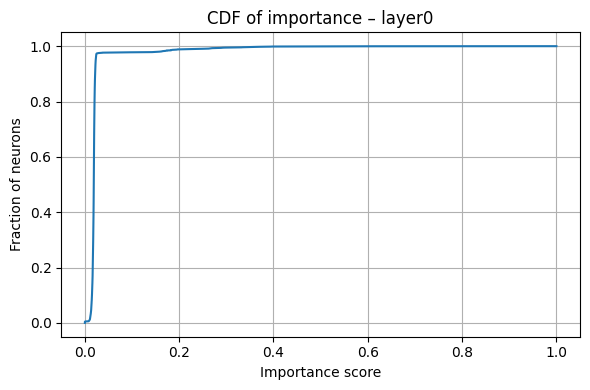

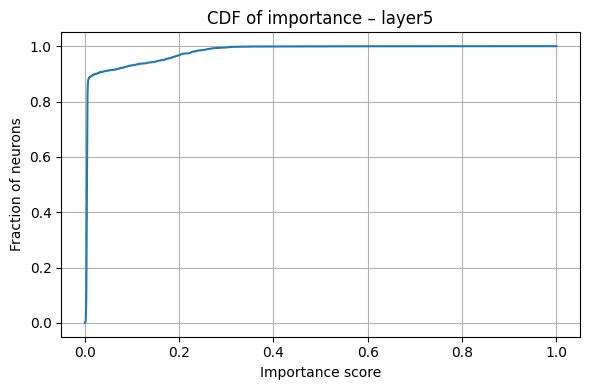

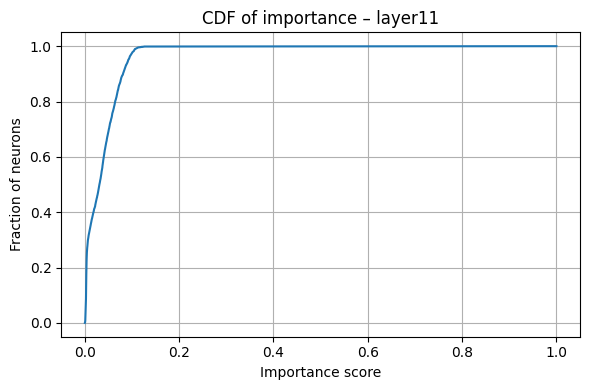

In [10]:
for layer in imp:
    x = np.sort(imp[layer])

    y = np.arange(1, len(x) + 1) / len(x)

    plt.figure(figsize=(6, 4))
    plt.plot(x, y)
    plt.title(f"CDF of importance – {layer}")
    plt.xlabel("Importance score")
    plt.ylabel("Fraction of neurons")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [11]:
percentiles = [50, 75, 90, 95, 97, 99, 99.5, 99.9]

for layer in imp:
    print(f"\n{layer}")
    for p in percentiles:
        v = np.percentile(imp[layer], p)
        print(f"  p{p:>5}: {v:.6f}")


layer0
  p   50: 0.018914
  p   75: 0.020150
  p   90: 0.021791
  p   95: 0.023004
  p   97: 0.024213
  p   99: 0.228561
  p 99.5: 0.308190
  p 99.9: 0.455087

layer5
  p   50: 0.004350
  p   75: 0.005073
  p   90: 0.023841
  p   95: 0.167082
  p   97: 0.203336
  p   99: 0.262921
  p 99.5: 0.299054
  p 99.9: 0.424871

layer11
  p   50: 0.030840
  p   75: 0.057593
  p   90: 0.080954
  p   95: 0.092023
  p   97: 0.097854
  p   99: 0.106746
  p 99.5: 0.112859
  p 99.9: 0.283218


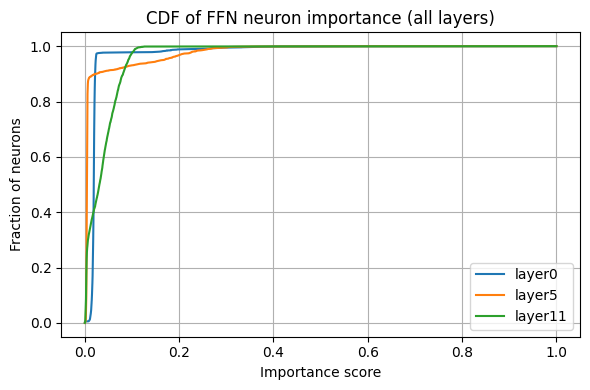

In [12]:
plt.figure(figsize=(6, 4))

for layer in imp:
    x = np.sort(imp[layer])
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=layer)

plt.xlabel("Importance score")
plt.ylabel("Fraction of neurons")
plt.title("CDF of FFN neuron importance (all layers)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# from transformers import (
#     AutoTokenizer,
#     AutoModelForSequenceClassification,
#     DataCollatorWithPadding,
# )

# layer = 6
# model = AutoModelForSequenceClassification.from_pretrained(
#     "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/full/finetuned_model_full"
# )
# imp = np.load("/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/full/importance_ffn_full.npz")
# imp_layer = imp["layer11"]
# W = model.bert.encoder.layer[layer].intermediate.dense.weight.detach().cpu().numpy()
# norms = np.linalg.norm(W, axis=1)

# plt.scatter(norms, imp_layer, alpha=0.3)
# plt.xlabel("weight L2 norm")
# plt.ylabel("PG importance")
# plt.title("Importance vs weight magnitude (full model)")
# plt.show()

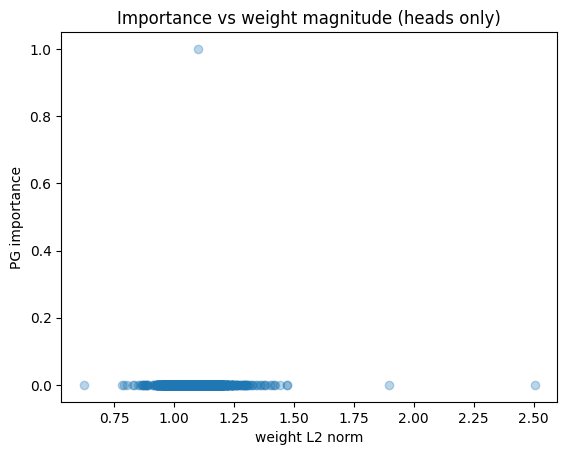

In [16]:
layer = 11
model = AutoModelForSequenceClassification.from_pretrained(
    "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/fine_tuned_model"
)
imp = np.load("/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/importance_ffn.npz")
imp_layer = imp["layer11"]
W = model.bert.encoder.layer[layer].intermediate.dense.weight.detach().cpu().numpy()
norms = np.linalg.norm(W, axis=1)

plt.scatter(norms, imp_layer, alpha=0.3)
plt.xlabel("weight L2 norm")
plt.ylabel("PG importance")
plt.title("Importance vs weight magnitude (heads only)")
plt.show()

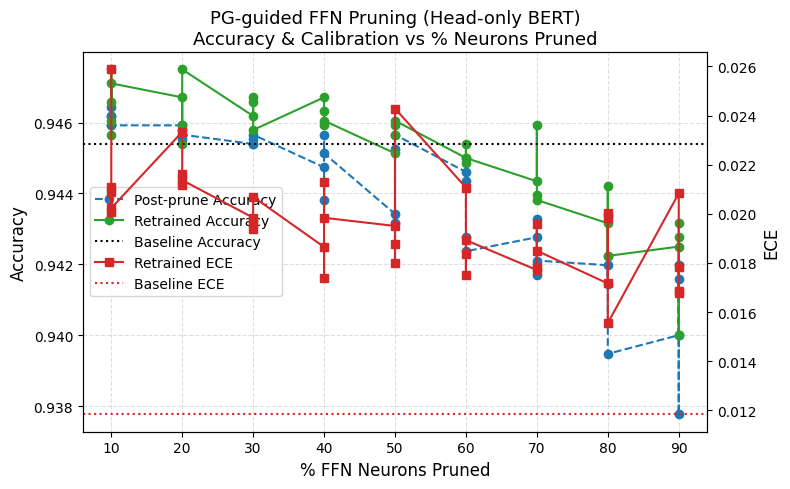

In [17]:
# -----------------------------
# Load CSV (head-only results)
# -----------------------------
csv_path = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/head/sweep_results.csv"   # update path if needed
df_head = pd.read_csv(csv_path)

# Sort by pruning percentage (important!)
df_head = df_head.sort_values("pruned_pct_overall")

# -----------------------------
# Extract values
# -----------------------------
x = df_head["pruned_pct_overall"]

baseline_acc = df_head["baseline_acc"].iloc[0]
baseline_ece = df_head["baseline_ece"].iloc[0]

postprune_acc = df_head["postprune_acc"]
retrain_acc = df_head["best_retrain_acc"]

retrain_ece = df_head["best_retrain_ece"]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))

# --- Accuracy axis (left) ---
ax1 = plt.gca()
ax1.plot(x, postprune_acc, marker="o", linestyle="--",
         label="Post-prune Accuracy", color="tab:blue")
ax1.plot(x, retrain_acc, marker="o", linestyle="-",
         label="Retrained Accuracy", color="tab:green")
ax1.axhline(baseline_acc, linestyle=":", color="black",
            label="Baseline Accuracy")

ax1.set_xlabel("% FFN Neurons Pruned", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.tick_params(axis="y")
ax1.grid(True, linestyle="--", alpha=0.4)

# --- ECE axis (right) ---
ax2 = ax1.twinx()
ax2.plot(x, retrain_ece, marker="s", linestyle="-",
         label="Retrained ECE", color="tab:red")
ax2.axhline(baseline_ece, linestyle=":", color="tab:red",
            label="Baseline ECE")

ax2.set_ylabel("ECE", fontsize=12)
ax2.tick_params(axis="y")

# -----------------------------
# Legend (combined)
# -----------------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc="center left", fontsize=10)

# -----------------------------
# Title & save
# -----------------------------
plt.title(
    "PG-guided FFN Pruning (Head-only BERT)\nAccuracy & Calibration vs % Neurons Pruned",
    fontsize=13
)

plt.tight_layout()
plt.savefig("accuracy_ece_vs_pruned_head.png", dpi=600)
plt.show()

In [18]:
df_head.head(10)

,timestamp,model_mode,pruning_method,model_name,target_layers,threshold,pruned_pct_overall,baseline_acc,baseline_ece,postprune_acc,postprune_ece,best_retrain_acc,best_retrain_ece,epochs,lr,seed,per_layer_pruned_pct
0,2026-01-09 14:04:44,head,pg,bert-base-uncased,"0,5,11",0.1,10.026042,0.945395,0.011831,0.946184,0.009274,0.946579,0.025878,2,0.00050,42,"{0: 10.026041666666663, 5: 10.026041666666663,..."
1,2026-01-09 16:21:42,head,pg,bert-base-uncased,"0,5,11",0.1,10.026042,0.945395,0.011831,0.946184,0.010836,0.947500,0.020071,2,0.00002,42,"{0: 10.026041666666663, 5: 10.026041666666663,..."
12,2026-01-22 15:19:42,l2,head,bert-base-uncased,"0,5,11",0.1,10.026042,0.945395,0.011831,0.945921,0.009962,0.946053,0.020906,2,0.00002,42,"{0: 10.026041666666663, 5: 10.026041666666663,..."
11,2026-01-22 15:17:00,l1,head,bert-base-uncased,"0,5,11",0.1,10.026042,0.945395,0.011831,0.946447,0.009440,0.945658,0.021103,2,0.00002,42,"{0: 10.026041666666663, 5: 10.026041666666663,..."
10,2026-01-22 15:13:12,random,head,bert-base-uncased,"0,5,11",0.1,10.026042,0.945395,0.011831,0.945921,0.011885,0.947105,0.020230,2,0.00002,42,"{0: 10.026041666666663, 5: 10.026041666666663,..."
2,2026-01-09 14:19:09,head,pg,bert-base-uncased,"0,5,11",0.2,20.019531,0.945395,0.011831,0.945921,0.009810,0.946711,0.023334,2,0.00050,42,"{0: 20.01953125, 5: 20.01953125, 11: 20.01953125}"
15,2026-01-22 15:57:32,l2,head,bert-base-uncased,"0,5,11",0.2,20.019531,0.945395,0.011831,0.945526,0.009210,0.945921,0.021613,2,0.00002,42,"{0: 20.01953125, 5: 20.01953125, 11: 20.01953125}"
14,2026-01-22 15:54:49,l1,head,bert-base-uncased,"0,5,11",0.2,20.019531,0.945395,0.011831,0.945789,0.008990,0.945395,0.021175,2,0.00002,42,"{0: 20.01953125, 5: 20.01953125, 11: 20.01953125}"
13,2026-01-22 15:51:09,random,head,bert-base-uncased,"0,5,11",0.2,20.019531,0.945395,0.011831,0.945658,0.009159,0.947500,0.021370,2,0.00002,42,"{0: 20.01953125, 5: 20.01953125, 11: 20.01953125}"
17,2026-01-22 16:32:40,l1,head,bert-base-uncased,"0,5,11",0.3,30.013021,0.945395,0.011831,0.945395,0.010700,0.946184,0.019840,2,0.00002,42,"{0: 30.013020833333336, 5: 30.013020833333336,..."


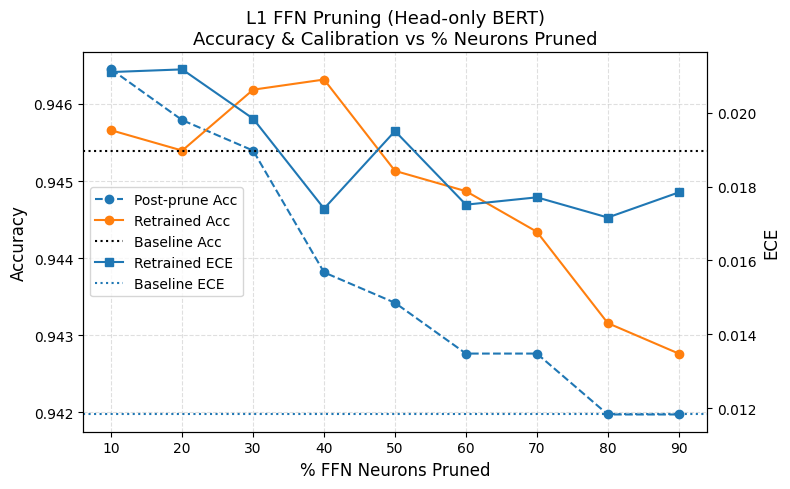

Saved: ./plots/accuracy_ece_vs_pruned_head_l1.png


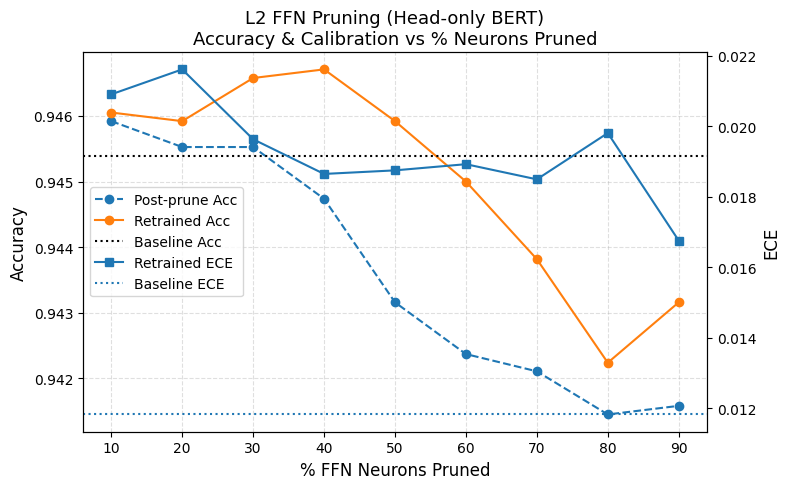

Saved: ./plots/accuracy_ece_vs_pruned_head_l2.png


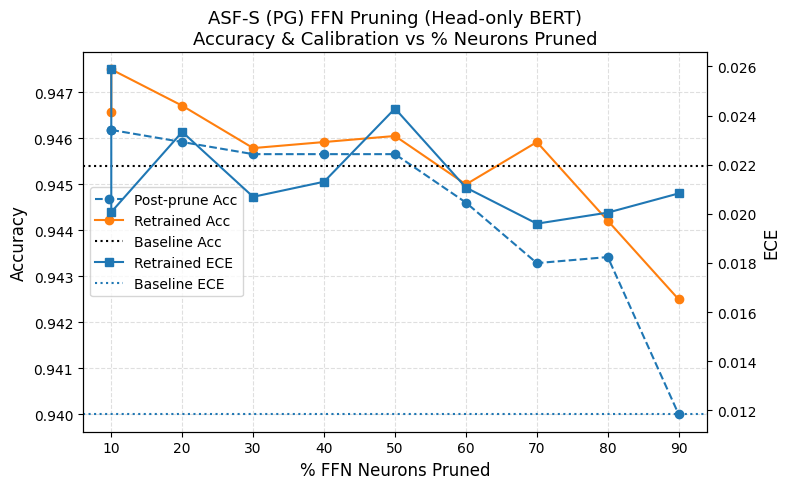

Saved: ./plots/accuracy_ece_vs_pruned_head_pg.png


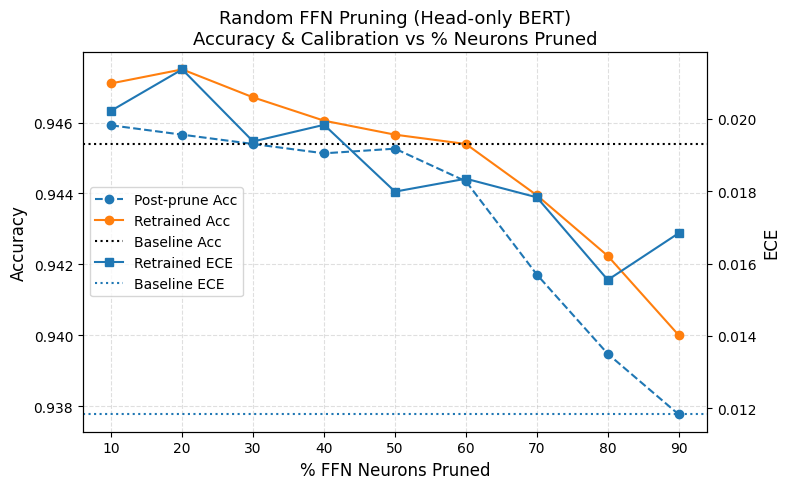

Saved: ./plots/accuracy_ece_vs_pruned_head_random.png


In [19]:

# -----------------------------
# Config
# -----------------------------
csv_path = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/head/sweep_results.csv"
out_dir = "./plots"
os.makedirs(out_dir, exist_ok=True)

# Methods you want (you can add more later)
METHOD_LABELS = {
    "pg": "ASF-S (PG)",
    "l1": "L1",
    "l2": "L2",
    "random": "Random",
}

VALID_MODES = {"head", "full"}
VALID_METHODS = set(METHOD_LABELS.keys())  # extend automatically if you add new methods later

# -----------------------------
# Load + clean
# -----------------------------
df = pd.read_csv(csv_path)

# --- Fix swapped (model_mode, pruning_method) rows ---
# If model_mode accidentally contains a method and pruning_method contains a mode, swap them back.
swap_mask = df["model_mode"].isin(VALID_METHODS) & df["pruning_method"].isin(VALID_MODES)
if swap_mask.any():
    df.loc[swap_mask, ["model_mode", "pruning_method"]] = df.loc[swap_mask, ["pruning_method", "model_mode"]].values

# Keep only head-only if that’s what you want to report
df = df[df["model_mode"] == "head"].copy()

# Ensure numeric types (important when CSV has mixed strings)
num_cols = [
    "pruned_pct_overall", "baseline_acc", "baseline_ece",
    "postprune_acc", "postprune_ece",
    "best_retrain_acc", "best_retrain_ece"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop broken rows
df = df.dropna(subset=["pruned_pct_overall", "baseline_acc", "baseline_ece"])

# Baselines (assumes constant baseline across rows)
baseline_acc = df["baseline_acc"].dropna().iloc[0]
baseline_ece = df["baseline_ece"].dropna().iloc[0]

# Sort for clean line connections
df = df.sort_values(["pruning_method", "pruned_pct_overall"])

# -----------------------------
# Plot per method separately
# -----------------------------
for method, dfm in df.groupby("pruning_method"):
    if dfm.empty:
        continue

    label = METHOD_LABELS.get(method, method)

    x = dfm["pruned_pct_overall"]
    post_acc = dfm["postprune_acc"]
    retrain_acc = dfm["best_retrain_acc"]
    retrain_ece = dfm["best_retrain_ece"]

    plt.figure(figsize=(8, 5))
    ax1 = plt.gca()

    # Accuracy (left)
    ax1.plot(x, post_acc, marker="o", linestyle="--", label="Post-prune Acc")
    ax1.plot(x, retrain_acc, marker="o", linestyle="-", label="Retrained Acc")
    ax1.axhline(baseline_acc, linestyle=":", color="black", label="Baseline Acc")

    ax1.set_xlabel("% FFN Neurons Pruned", fontsize=12)
    ax1.set_ylabel("Accuracy", fontsize=12)
    ax1.grid(True, linestyle="--", alpha=0.4)

    # ECE (right)
    ax2 = ax1.twinx()
    ax2.plot(x, retrain_ece, marker="s", linestyle="-", label="Retrained ECE")
    ax2.axhline(baseline_ece, linestyle=":", label="Baseline ECE")

    ax2.set_ylabel("ECE", fontsize=12)

    # Combined legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center left", fontsize=10)

    plt.title(f"{label} FFN Pruning (Head-only BERT)\nAccuracy & Calibration vs % Neurons Pruned", fontsize=13)
    plt.tight_layout()

    out_path = os.path.join(out_dir, f"accuracy_ece_vs_pruned_head_{method}.png")
    plt.savefig(out_path, dpi=600)
    plt.show()

    print(f"Saved: {out_path}")

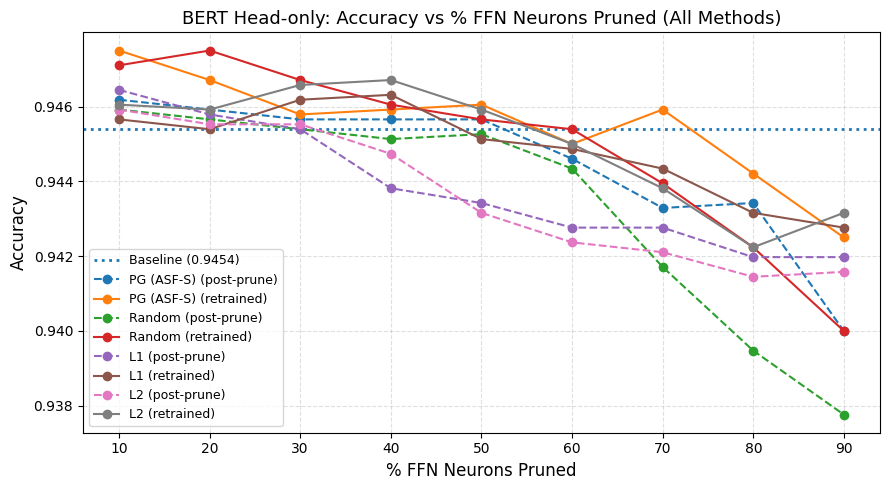

Saved: accuracy_all_methods_head.png


In [20]:

csv_path = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/head/sweep_results.csv"
out_path = "accuracy_all_methods_head.png"

METHOD_ORDER = ["pg", "random", "l1", "l2"]   # plot order
METHOD_LABELS = {
    "pg": "PG (ASF-S)",
    "random": "Random",
    "l1": "L1",
    "l2": "L2",
}

VALID_MODES = {"head", "full"}
VALID_METHODS = set(METHOD_LABELS.keys())

# -----------------------------
# Load + fix swapped rows
# -----------------------------
df = pd.read_csv(csv_path)

swap_mask = df["model_mode"].isin(VALID_METHODS) & df["pruning_method"].isin(VALID_MODES)
if swap_mask.any():
    df.loc[swap_mask, ["model_mode", "pruning_method"]] = df.loc[swap_mask, ["pruning_method", "model_mode"]].values

# head-only
df = df[df["model_mode"] == "head"].copy()

# numeric safety
num_cols = ["pruned_pct_overall", "baseline_acc", "postprune_acc", "best_retrain_acc"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["pruned_pct_overall", "baseline_acc"])

baseline_acc = df["baseline_acc"].dropna().iloc[0]

# -----------------------------
# Plot: all methods on same axes
# -----------------------------
plt.figure(figsize=(9, 5))
ax = plt.gca()

# Baseline
ax.axhline(baseline_acc, linestyle=":", linewidth=2, label=f"Baseline ({baseline_acc:.4f})")

# Choose what to plot:
PLOT_POSTPRUNE = True
PLOT_RETRAINED = True

# Group by method and plot
for method in METHOD_ORDER:
    dfm = df[df["pruning_method"] == method].copy()
    if dfm.empty:
        continue

    # If you have multiple runs per pruned_pct (e.g., different lr), keep the best retrain acc per pruned %
    # and the best postprune acc per pruned %.
    dfm = dfm.sort_values("pruned_pct_overall")
    dfm_agg = dfm.groupby("pruned_pct_overall", as_index=False).agg({
        "postprune_acc": "max",
        "best_retrain_acc": "max",
    }).sort_values("pruned_pct_overall")

    x = dfm_agg["pruned_pct_overall"]
    label = METHOD_LABELS.get(method, method)

    if PLOT_POSTPRUNE and "postprune_acc" in dfm_agg:
        ax.plot(x, dfm_agg["postprune_acc"], marker="o", linestyle="--",
                label=f"{label} (post-prune)")

    if PLOT_RETRAINED and "best_retrain_acc" in dfm_agg:
        ax.plot(x, dfm_agg["best_retrain_acc"], marker="o", linestyle="-",
                label=f"{label} (retrained)")

ax.set_xlabel("% FFN Neurons Pruned", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_title("BERT Head-only: Accuracy vs % FFN Neurons Pruned (All Methods)", fontsize=13)

ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig(out_path, dpi=600)
plt.show()

print("Saved:", out_path)

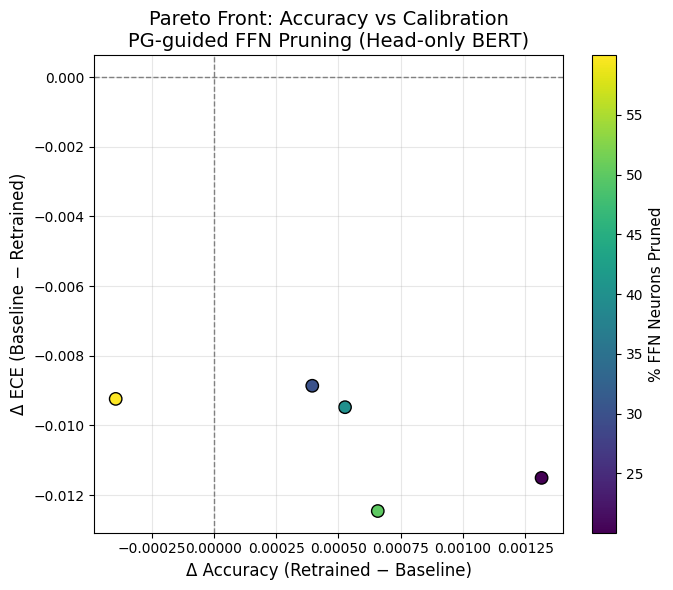

In [ ]:
# Load your sweep CSV
csv_path = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/head/sweep_results.csv" 
df = pd.read_csv(csv_path)

# Compute deltas
df["delta_acc"] = df["best_retrain_acc"] - df["baseline_acc"]
df["delta_ece"] = df["baseline_ece"] - df["best_retrain_ece"]

# Sort by pruning percentage (nice for coloring)
df = df.sort_values("pruned_pct_overall")

plt.figure(figsize=(7, 6))

sc = plt.scatter(
    df["delta_acc"],
    df["delta_ece"],
    c=df["pruned_pct_overall"],
    cmap="viridis",
    s=80,
    edgecolors="k"
)

plt.axvline(0, linestyle="--", color="gray", linewidth=1)
plt.axhline(0, linestyle="--", color="gray", linewidth=1)

plt.xlabel("Δ Accuracy (Retrained − Baseline)", fontsize=12)
plt.ylabel("Δ ECE (Baseline − Retrained)", fontsize=12)
plt.title("Pareto Front: Accuracy vs Calibration\nPG-guided FFN Pruning (Head-only BERT)", fontsize=14)

cbar = plt.colorbar(sc)
cbar.set_label("% FFN Neurons Pruned", fontsize=11)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

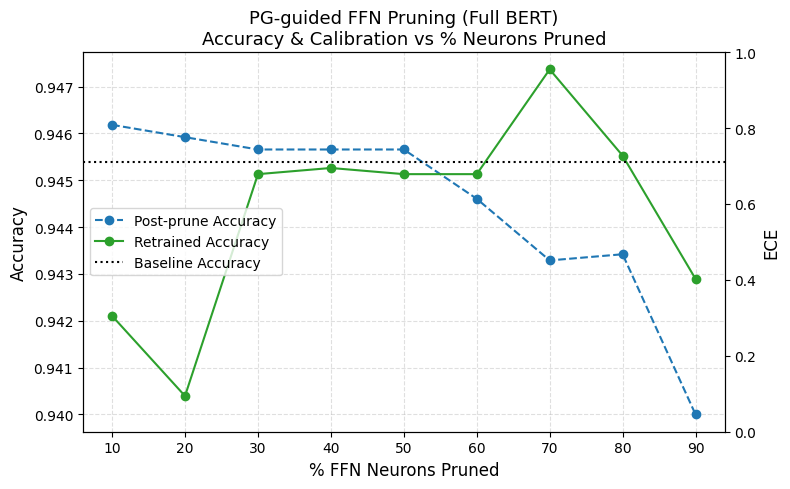

In [ ]:
# -----------------------------
# Load CSV (head-only results)
# -----------------------------
csv_path = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/full/sweep_results.csv"   # update path if needed
df_full = pd.read_csv(csv_path)

# Sort by pruning percentage (important!)
df_full = df_full.sort_values("pruned_pct_overall")

# -----------------------------
# Extract values
# -----------------------------
x = df_full["pruned_pct_overall"]

baseline_acc = df_full["baseline_acc"].iloc[0]
baseline_ece = df_full["baseline_ece"].iloc[0]

postprune_acc = df_full["postprune_acc"]
retrain_acc = df_full["best_retrain_acc"]

retrain_ece = df_full["best_retrain_ece"]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))

# --- Accuracy axis (left) ---
ax1 = plt.gca()
ax1.plot(x, postprune_acc, marker="o", linestyle="--",
         label="Post-prune Accuracy", color="tab:blue")
ax1.plot(x, retrain_acc, marker="o", linestyle="-",
         label="Retrained Accuracy", color="tab:green")
ax1.axhline(baseline_acc, linestyle=":", color="black",
            label="Baseline Accuracy")

ax1.set_xlabel("% FFN Neurons Pruned", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.tick_params(axis="y")
ax1.grid(True, linestyle="--", alpha=0.4)

# --- ECE axis (right) ---
ax2 = ax1.twinx()
# ax2.plot(x, retrain_ece, marker="s", linestyle="-",
#          label="Retrained ECE", color="tab:red")
# ax2.axhline(baseline_ece, linestyle=":", color="tab:red",
#             label="Baseline ECE")

ax2.set_ylabel("ECE", fontsize=12)
ax2.tick_params(axis="y")

# -----------------------------
# Legend (combined)
# -----------------------------
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc="center left", fontsize=10)

# -----------------------------
# Title & save
# -----------------------------
plt.title(
    "PG-guided FFN Pruning (Full BERT)\nAccuracy & Calibration vs % Neurons Pruned",
    fontsize=13
)

plt.tight_layout()
plt.savefig("accuracy_ece_vs_pruned_full.png", dpi=300)
plt.show()

In [ ]:
df_full.head(10)

,timestamp,model_mode,model_name,target_layers,threshold,pruned_pct_overall,baseline_acc,baseline_ece,postprune_acc,postprune_ece,best_retrain_acc,best_retrain_ece,epochs,lr,seed,per_layer_pruned_pct
0,2026-01-09 14:25:05,full,bert-base-uncased,"0,5,11",0.1,10.026042,0.945395,0.011831,0.946184,0.009274,0.942105,0.028849,2,0.00002,42,"{0: 10.026041666666663, 5: 10.026041666666663,..."
1,2026-01-09 14:59:51,full,bert-base-uncased,"0,5,11",0.2,20.019531,0.945395,0.011831,0.945921,0.009810,0.940395,0.025649,2,0.00002,42,"{0: 20.01953125, 5: 20.01953125, 11: 20.01953125}"
2,2026-01-09 15:34:59,full,bert-base-uncased,"0,5,11",0.3,30.013021,0.945395,0.011831,0.945658,0.010385,0.945132,0.019059,2,0.00002,42,"{0: 30.013020833333336, 5: 30.013020833333336,..."
3,2026-01-09 16:21:42,full,bert-base-uncased,"0,5,11",0.4,40.006510,0.945395,0.011831,0.945658,0.009849,0.945263,0.013610,2,0.00002,42,"{0: 40.006510416666664, 5: 40.006510416666664,..."
4,2026-01-09 16:53:19,full,bert-base-uncased,"0,5,11",0.5,50.000000,0.945395,0.011831,0.945658,0.009386,0.945132,0.027320,2,0.00002,42,"{0: 50.0, 5: 50.0, 11: 50.0}"
5,2026-01-09 17:10:42,full,bert-base-uncased,"0,5,11",0.6,59.993490,0.945395,0.011831,0.944605,0.008882,0.945132,0.017826,2,0.00002,42,"{0: 59.99348958333333, 5: 59.99348958333333, 1..."
6,2026-01-09 17:28:03,full,bert-base-uncased,"0,5,11",0.7,69.986979,0.945395,0.011831,0.943289,0.010552,0.947368,0.013700,2,0.00002,42,"{0: 69.98697916666667, 5: 69.98697916666667, 1..."
7,2026-01-09 17:45:24,full,bert-base-uncased,"0,5,11",0.8,79.980469,0.945395,0.011831,0.943421,0.008900,0.945526,0.017436,2,0.00002,42,"{0: 79.98046875, 5: 79.98046875, 11: 79.98046875}"
8,2026-01-09 18:02:45,full,bert-base-uncased,"0,5,11",0.9,89.973958,0.945395,0.011831,0.940000,0.006097,0.942895,0.024768,2,0.00002,42,"{0: 89.97395833333334, 5: 89.97395833333334, 1..."


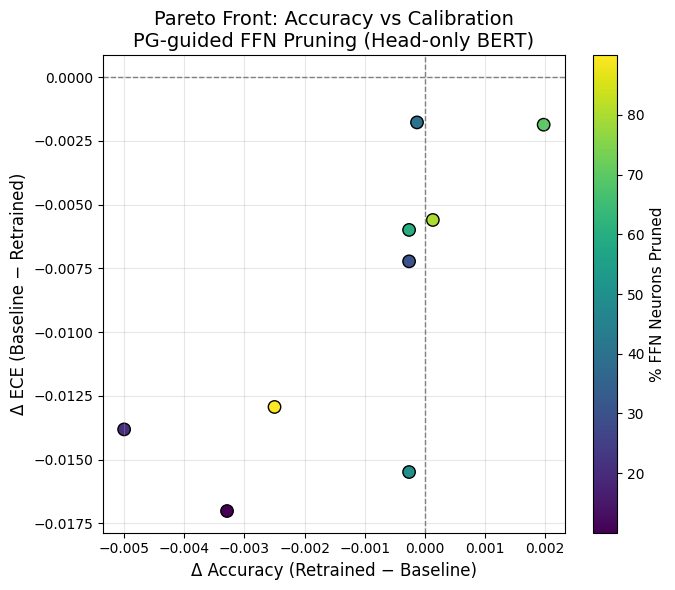

In [ ]:
# Compute deltas
df_full["delta_acc"] = df_full["best_retrain_acc"] - df_full["baseline_acc"]
df_full["delta_ece"] = df_full["baseline_ece"] - df_full["best_retrain_ece"]
# Sort by pruning percentage (nice for coloring)
df_full = df_full.sort_values("pruned_pct_overall")

plt.figure(figsize=(7, 6))

sc = plt.scatter(
    df_full["delta_acc"],
    df_full["delta_ece"],
    c=df_full["pruned_pct_overall"],
    cmap="viridis",
    s=80,
    edgecolors="k"
)

plt.axvline(0, linestyle="--", color="gray", linewidth=1)
plt.axhline(0, linestyle="--", color="gray", linewidth=1)

plt.xlabel("Δ Accuracy (Retrained − Baseline)", fontsize=12)
plt.ylabel("Δ ECE (Baseline − Retrained)", fontsize=12)
plt.title("Pareto Front: Accuracy vs Calibration\nPG-guided FFN Pruning (Head-only BERT)", fontsize=14)

cbar = plt.colorbar(sc)
cbar.set_label("% FFN Neurons Pruned", fontsize=11)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
df = pd.read_csv("/home/charuka09/Documents/postPhD/mindula/icml/Bert/sweep_results.csv")
# df = pd.read_csv("/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/head/sweep_results.csv")

df_head = df[df["model_mode"] == "head"].copy()
df_full = df[df["model_mode"] == "full"].copy()

for d in [df_head, df_full]:
    d["delta_acc"] = d["best_retrain_acc"] - d["baseline_acc"]
    d["delta_ece"] = d["baseline_ece"] - d["best_retrain_ece"]

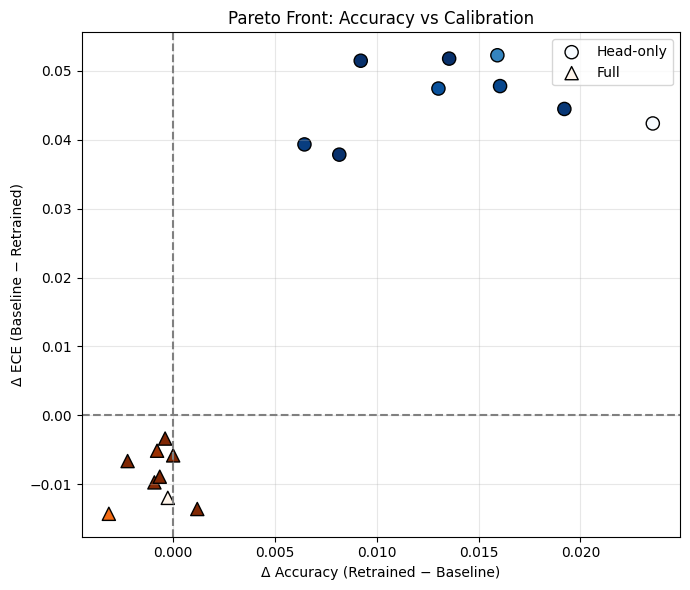

In [31]:
plt.figure(figsize=(7, 6))

plt.scatter(
    df_head["delta_acc"], df_head["delta_ece"],
    c=df_head["pruned_pct_overall"],
    cmap="Blues", s=90, edgecolor="k", label="Head-only"
)

plt.scatter(
    df_full["delta_acc"], df_full["delta_ece"],
    c=df_full["pruned_pct_overall"],
    cmap="Oranges", s=90, edgecolor="k", marker="^", label="Full"
)

plt.axvline(0, linestyle="--", color="gray")
plt.axhline(0, linestyle="--", color="gray")

plt.xlabel("Δ Accuracy (Retrained − Baseline)")
plt.ylabel("Δ ECE (Baseline − Retrained)")
plt.title("Pareto Front: Accuracy vs Calibration")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

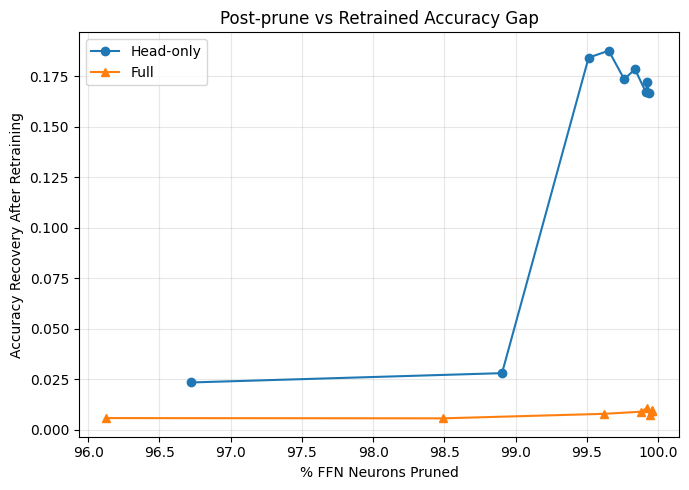

In [32]:
df_head["acc_recovery"] = df_head["best_retrain_acc"] - df_head["postprune_acc"]
df_full["acc_recovery"] = df_full["best_retrain_acc"] - df_full["postprune_acc"]

plt.figure(figsize=(7, 5))

plt.plot(
    df_head["pruned_pct_overall"], df_head["acc_recovery"],
    "o-", label="Head-only"
)
plt.plot(
    df_full["pruned_pct_overall"], df_full["acc_recovery"],
    "^-", label="Full"
)

plt.xlabel("% FFN Neurons Pruned")
plt.ylabel("Accuracy Recovery After Retraining")
plt.title("Post-prune vs Retrained Accuracy Gap")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
import ast

def expand_layer_stats(df):
    rows = []
    for _, r in df.iterrows():
        per_layer = ast.literal_eval(r["per_layer_pruned_pct"])
        for layer, pct in per_layer.items():
            rows.append({
                "model_mode": r["model_mode"],
                "layer": int(layer),
                "pruned_pct": pct
            })
    return pd.DataFrame(rows)

layer_df = expand_layer_stats(df)

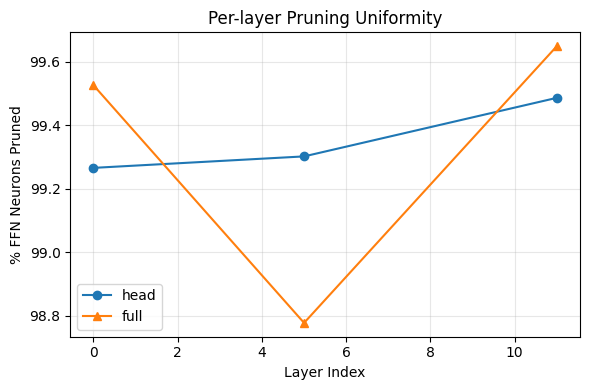

In [35]:
plt.figure(figsize=(6, 4))

for mode, marker in [("head", "o"), ("full", "^")]:
    sub = layer_df[layer_df["model_mode"] == mode]
    means = sub.groupby("layer")["pruned_pct"].mean()
    plt.plot(means.index, means.values, marker+"-", label=mode)

plt.xlabel("Layer Index")
plt.ylabel("% FFN Neurons Pruned")
plt.title("Per-layer Pruning Uniformity")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
csv_path = "/home/charuka09/Documents/postPhD/mindula/icml/Bert/agnews/head/sweep_results.csv"
df = pd.read_csv(csv_path)

# --- clean up ---
# some of your earlier rows had columns swapped; enforce standard names if needed
# (skip if already consistent)
# df.rename(columns={"model_mode": "model_mode"}, inplace=True)

# Ensure numeric
num_cols = ["pruned_pct_overall", "baseline_acc", "baseline_ece",
            "postprune_acc", "postprune_ece", "best_retrain_acc", "best_retrain_ece"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- ICML-friendly sparse points (edit these) ---
targets = [10, 30, 50, 70, 90]

# Methods to show and their display names
method_order = ["pg", "random", "l1", "l2"]
method_name = {
    "pg": "PG (ASF-S)",
    "random": "Random",
    "l1": "L1",
    "l2": "L2",
}

# Baseline (take first row)
baseline_acc = float(df["baseline_acc"].dropna().iloc[0])
baseline_ece = float(df["baseline_ece"].dropna().iloc[0])

rows = []
for m in method_order:
    d_m = df[df["pruning_method"].astype(str).str.lower() == m].copy()
    if d_m.empty:
        continue

    for t in targets:
        # closest prune pct to target t
        d_m["dist"] = (d_m["pruned_pct_overall"] - t).abs()
        closest = d_m.sort_values(["dist", "pruned_pct_overall"]).head(20)  # take a small band
        if closest.empty:
            rows.append((method_name[m], t, None, None))
            continue

        # if multiple configs fall near same target, keep best (acc desc, ece asc)
        best = closest.sort_values(["best_retrain_acc", "best_retrain_ece"],
                                   ascending=[False, True]).iloc[0]

        rows.append((
            method_name[m],
            float(best["pruned_pct_overall"]),
            float(best["best_retrain_acc"]),
            float(best["best_retrain_ece"]),
        ))

# ---- Print LaTeX ----
def fmt(x, k=4):
    if x is None or (isinstance(x, float) and (np.isnan(x))):
        return "--"
    return f"{x:.{k}f}"

print(r"\begin{table}[t]")
print(r"\centering")
print(r"\small")
print(r"\begin{tabular}{l c c c}")
print(r"\toprule")
print(r"\textbf{Method} & \textbf{Pruned (\%)} & \textbf{Accuracy} $\uparrow$ & \textbf{ECE} $\downarrow$ \\")
print(r"\midrule")
print(f"Baseline (no pruning) & 0 & {baseline_acc:.4f} & {baseline_ece:.4f} \\\\")
print(r"\midrule")

cur_method = None
for method, pruned, acc, ece in rows:
    if cur_method is not None and method != cur_method:
        print(r"\midrule")
    cur_method = method
    print(f"{method} & {fmt(pruned, 1)} & {fmt(acc, 4)} & {fmt(ece, 4)} \\\\")

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\caption{Head-only structured FFN pruning on BERT-base (AG News). "
      r"Best retrained accuracy and calibration (ECE) at matched sparsity targets.}")
print(r"\label{tab:bert_head_pruning}")
print(r"\end{table}")

\begin{table}[t]
\centering
\small
\begin{tabular}{l c c c}
\toprule
\textbf{Method} & \textbf{Pruned (\%)} & \textbf{Accuracy} $\uparrow$ & \textbf{ECE} $\downarrow$ \\
\midrule
Baseline (no pruning) & 0 & 0.9454 & 0.0118 \\
\midrule
PG (ASF-S) & 10.0 & 0.9475 & 0.0201 \\
PG (ASF-S) & 10.0 & 0.9475 & 0.0201 \\
PG (ASF-S) & 10.0 & 0.9475 & 0.0201 \\
PG (ASF-S) & 10.0 & 0.9475 & 0.0201 \\
PG (ASF-S) & 10.0 & 0.9475 & 0.0201 \\
\bottomrule
\end{tabular}
\caption{Head-only structured FFN pruning on BERT-base (AG News). Best retrained accuracy and calibration (ECE) at matched sparsity targets.}
\label{tab:bert_head_pruning}
\end{table}
